# Access the databases


In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import numpy as np

In [16]:
birds_db_path = "birds.db"

birds_conn = sqlite3.connect(birds_db_path)

birds_df = pd.read_sql_query("SELECT * FROM birds", birds_conn)

birds_conn.close()

birds_df.head(3)

,id,scientific_name,common_name,confidence,sighting_time,location_name,latitude,longitude
0,0,Helopsaltes ochotensis,Middendorff's Grasshopper Warbler,0.923046,2024-09-23 22:22:24,BirdNETPi,45.08,-93.0227
1,1,Helopsaltes ochotensis,Middendorff's Grasshopper Warbler,0.801097,2024-09-23 22:22:39,BirdNETPi,45.08,-93.0227
2,2,Helopsaltes ochotensis,Middendorff's Grasshopper Warbler,0.908401,2024-09-23 22:22:39,BirdNETPi,45.08,-93.0227


In [15]:
ebirds_db_path = "ebirds.db"

ebirds_conn = sqlite3.connect(ebirds_db_path)

ebirds_df = pd.read_sql_query("SELECT * FROM ebirds", ebirds_conn)
ebirds_extra_df = pd.read_sql_query("SELECT * FROM ebirds_extra", ebirds_conn)
ebirds_world_df = pd.read_sql_query("SELECT * FROM ebirds_world", ebirds_conn)

ebirds_conn.close()

# Plot all birds discovered

Number of unique birds: 67
Number of unique birds after minimum counts: 32


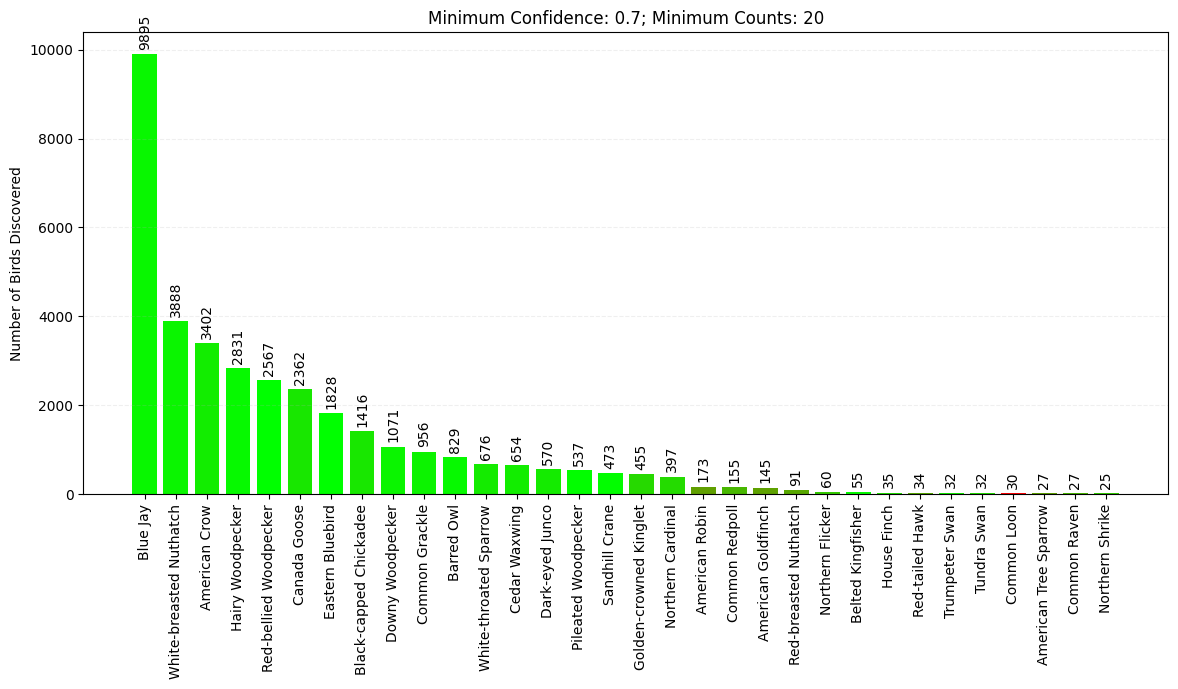

In [98]:
# filter out birds below a minimum confidence
min_confidence = 0.7
birds_df = birds_df[birds_df['confidence'] >= min_confidence]

# find all unique birds (by common name)
unique_birds = birds_df['common_name'].unique()
print("Number of unique birds:", len(unique_birds))

# use a minimum number of counts to count as a found bird
min_counts = 20
filtered_birds = birds_df['common_name'].value_counts()
filtered_birds = filtered_birds[filtered_birds >= min_counts].index
valid_common_names = birds_df['common_name'][birds_df['common_name'].isin(filtered_birds)].unique()
print("Number of unique birds after minimum counts:", len(valid_common_names))

# filter the birds db to only include the valid common names
filtered_db = birds_df[birds_df['common_name'].isin(valid_common_names)]

# reorder valid_common_names by the number of birds discovered
valid_common_names = filtered_db['common_name'].value_counts().index.tolist()

# get the highest confidence for each valid common name
highest_confidence = filtered_db.groupby('common_name')['confidence'].max()
# Normalize the highest confidence values to the range [0, 1] for colormap
norm = plt.Normalize(min_confidence, 1.0)
colors = cm.brg(norm(highest_confidence[valid_common_names]))

# plot the number of birds discovered for each unique bird
plt.figure(figsize=(14, 6))
plt.bar(valid_common_names, 
        filtered_db['common_name'].value_counts().reindex(valid_common_names), 
        color=colors)
plt.ylabel('Number of Birds Discovered')
plt.title(f"Minimum Confidence: {min_confidence}; Minimum Counts: {min_counts}")
plt.xticks(rotation=90)
# plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.2)
for i, count in enumerate(filtered_db['common_name'].value_counts().reindex(valid_common_names)):
    y_offset = 100
    plt.text(i, count + y_offset, str(count), ha='center', va='bottom', rotation=90)
plt.show()

# Plot by hour of the day

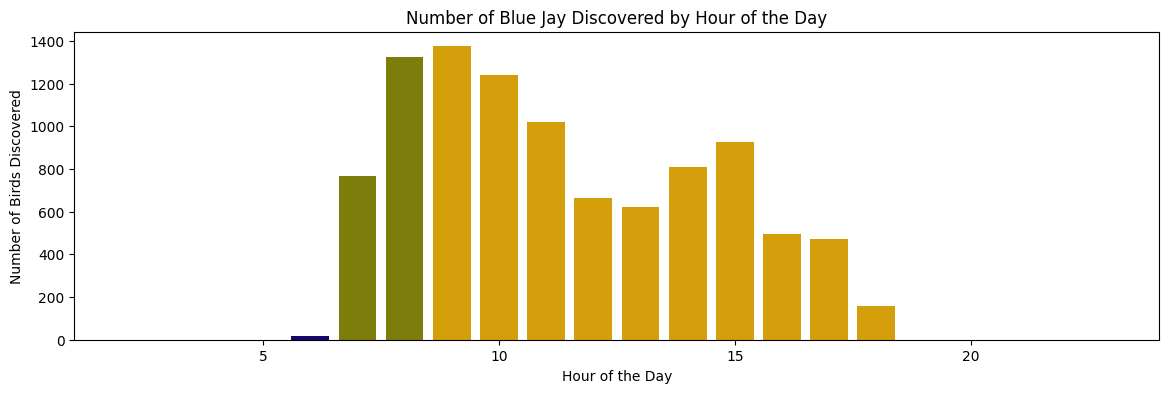

In [121]:
# pick a bird by common name
bird_name = "Blue Jay"
min_confidence = 0.7

# filter the birds db to only include the bird_name
just_this_bird = birds_df[birds_df['common_name'] == bird_name]
just_this_bird = just_this_bird[just_this_bird['confidence'] >= min_confidence]
just_this_bird = just_this_bird.sort_values(by='sighting_time')

# read the sighting time as a datetime
just_this_bird['sighting_time'] = pd.to_datetime(just_this_bird['sighting_time'])
# get the counts of this bird by the hour it was discovered (use sighting_time)
just_this_bird['hour'] = just_this_bird['sighting_time'].dt.hour
# just_this_bird.head()

# get the counts of this bird by the hour it was discovered
counts_by_hour = just_this_bird['hour'].value_counts()

def get_color(hour):
    if hour <= 6:
        return '#1a056e'
    elif hour > 6 and hour <= 8:
        return '#7d7d0b'
    elif hour > 8 and hour <= 19:
        return '#d49e0b'
    elif hour > 19 and hour <= 21:
        return '#7d7d0b'
    else:
        return '#1a056e'
    
# plot the counts of this bird by the hour it was discovered
plt.figure(figsize=(14, 4))
colors = [get_color(hour) for hour in counts_by_hour.index]
plt.bar(counts_by_hour.index, counts_by_hour.values, color=colors)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Birds Discovered')
plt.title(f"Number of {bird_name} Discovered by Hour of the Day")
plt.xlim(1, 24)
plt.show()

# Plot the occurence of a bird by month

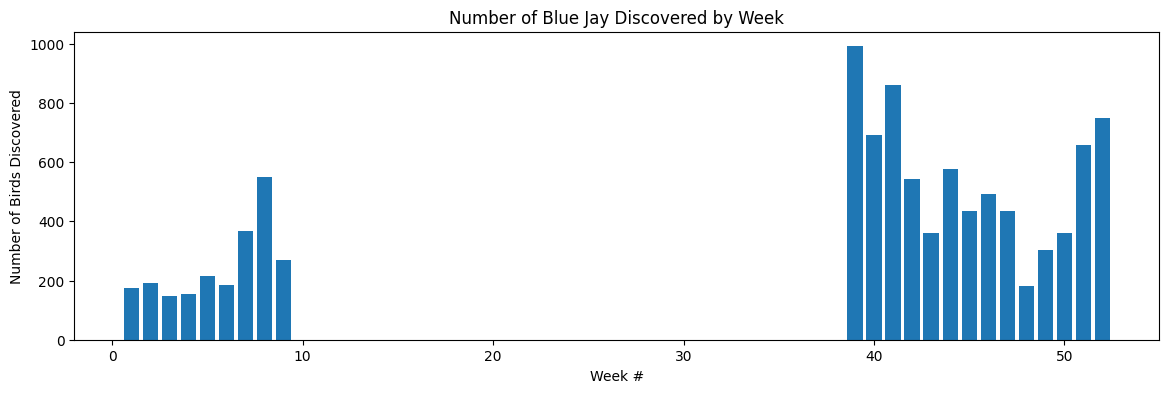

In [131]:
# pick a bird by common name
bird_name = "Blue Jay"
min_confidence = 0.7

# filter the birds db to only include the bird_name
just_this_bird = birds_df[birds_df['common_name'] == bird_name]
just_this_bird = just_this_bird[just_this_bird['confidence'] >= min_confidence]

# create a new column for the month
just_this_bird['sighting_time'] = pd.to_datetime(just_this_bird['sighting_time'])
just_this_bird['month'] = just_this_bird['sighting_time'].dt.month
just_this_bird['week'] = (just_this_bird['sighting_time'].dt.isocalendar().week)

# get the counts of this bird by month or month
counts_by_month = just_this_bird['month'].value_counts()
counts_by_week = just_this_bird['week'].value_counts()

# plot the counts of this bird by month
plt.figure(figsize=(14, 4))
plt.bar(counts_by_week.index, counts_by_week.values)
plt.xlabel('Week #')
plt.ylabel('Number of Birds Discovered')
plt.title(f"Number of {bird_name} Discovered by Week")
plt.show()


<Figure size 1400x1000 with 0 Axes>

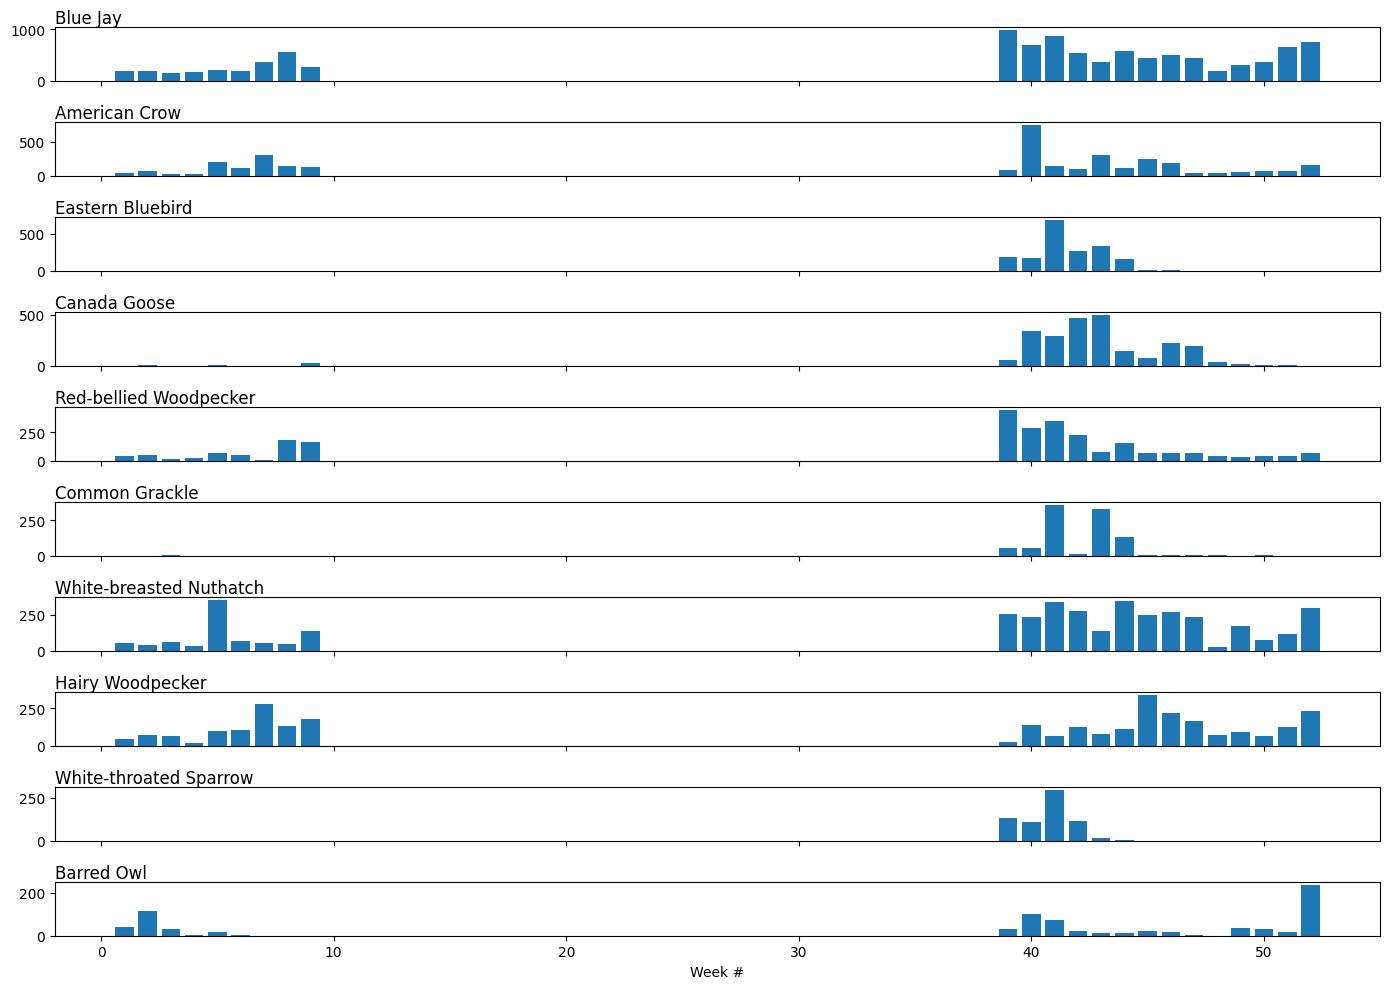

In [ ]:
# plot every bird by week with each bird getting its own row in a subplot
# pick a minimum confidence
min_confidence = 0.7

# only show the top X birds
num_birds_to_plot = 10

# filter the birds db to only include the birds with a confidence greater than or equal to the minimum confidence
filtered_birds = birds_df[birds_df['confidence'] >= min_confidence]

# add the columns to split up the sighting_time into year, month, week, hour
filtered_birds['sighting_time'] = pd.to_datetime(filtered_birds['sighting_time'])
filtered_birds['year'] = filtered_birds['sighting_time'].dt.year
filtered_birds['month'] = filtered_birds['sighting_time'].dt.month
filtered_birds['week'] = filtered_birds['sighting_time'].dt.isocalendar().week
filtered_birds['hour'] = filtered_birds['sighting_time'].dt.hour

# create a new dataframe with the counts of each bird by week
counts_by_week = filtered_birds.groupby(['common_name', 'week']).size().reset_index(name='count')
# Sort the counts by the number of birds discovered in descending order
counts_by_week = counts_by_week.sort_values(by='count', ascending=False)


# plot the counts of each bird by week
plt.figure(figsize=(14, 10))
unique_birds = counts_by_week['common_name'].unique()
num_birds = len(unique_birds)

# Create subplots
fig, axs = plt.subplots(num_birds_to_plot, 1, figsize=(14, 1 * num_birds_to_plot), sharex=True)

for i, bird in enumerate(unique_birds[:num_birds_to_plot]):
    bird_data = counts_by_week[counts_by_week['common_name'] == bird]
    axs[i].bar(bird_data['week'], bird_data['count'])
    axs[i].set_title(bird, loc='left', pad=0)

plt.xlabel('Week #')
plt.tight_layout()
plt.show()